In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

awards = pd.read_csv('Player Award Shares.csv')
awards.head()

,season,award,player,player_id,age,first,pts_won,pts_max,share,winner
0,2025,nba clutch_poy,Jalen Brunson,brunsja01,28,70.0,426.0,500.0,0.852,True
1,2025,nba clutch_poy,Nikola Jokić,jokicni01,29,26.0,312.0,500.0,0.624,False
2,2025,nba clutch_poy,Anthony Edwards,edwaran01,23,2.0,47.0,500.0,0.094,False
3,2025,nba clutch_poy,Trae Young,youngtr01,26,0.0,44.0,500.0,0.088,False
4,2025,nba clutch_poy,Stephen Curry,curryst01,36,1.0,27.0,500.0,0.054,False


In [62]:
mvp = awards[awards['award'] == 'nba mvp']
mvp.head()
print(mvp['season'].min(), mvp['season'].max())

1956 2025


In [63]:
mvp_winners = mvp[mvp['winner'] == True]
mvp_winners[['season', 'player', 'pts_won', 'pts_max', 'share']].head(10)

,season,player,pts_won,pts_max,share
39,2025,Shai Gilgeous-Alexander,913.0,1000.0,0.913
109,2024,Nikola Jokić,926.0,990.0,0.935
175,2023,Joel Embiid,915.0,1000.0,0.915
227,2022,Nikola Jokić,875.0,1000.0,0.875
295,2021,Nikola Jokić,971.0,1010.0,0.961
356,2020,Giannis Antetokounmpo,962.0,1010.0,0.952
417,2019,Giannis Antetokounmpo,941.0,1010.0,0.932
501,2018,James Harden,965.0,1010.0,0.955
570,2017,Russell Westbrook,888.0,1010.0,0.879
641,2016,Stephen Curry,1310.0,1310.0,1.000


In [64]:
stats = pd.read_csv("Player Per Game.csv")
stats.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp_per_game,...,ft_percent,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,73,57.0,23.9,...,0.554,2.4,4.3,6.7,1.4,0.9,0.7,0.9,1.7,10.1
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,22.8,...,0.580,4.5,4.1,8.6,1.5,0.7,0.6,1.1,1.7,5.8
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,32.4,...,0.778,2.0,8.0,10.0,3.2,1.2,0.7,1.6,1.7,20.1
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,62,13.0,15.7,...,0.837,0.7,1.5,2.3,0.8,0.4,0.3,0.5,1.5,5.1
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,15.5,...,0.862,0.8,1.5,2.3,0.7,0.4,0.3,0.5,1.8,4.3


In [65]:
# Filter stats to only NBA and from 1980 onwards
stats = stats[(stats['lg'] == 'NBA') & (stats['season'] >= 1980)]

# Merge stats with MVP voting data
df = stats.merge(mvp[['season', 'player_id', 'share', 'winner']],
                 on=['season', 'player_id'],
                 how='left')

# Fill players who got no MVP votes with 0
df['share'] = df['share'].fillna(0)
df['winner']= df['winner'].fillna(False)

print(df.shape)
print(df['winner'].value_counts())

(25349, 34)
winner
False    25303
True        46
Name: count, dtype: int64


C:\Users\david\AppData\Local\Temp\ipykernel_19092\3716973374.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['winner']= df['winner'].fillna(False)


In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

features = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'stl_per_game', 'blk_per_game', "mp_per_game", 'g']

X = df[features].fillna(0)
y = df['winner'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5059
           1       0.00      0.00      0.00        11

    accuracy                           1.00      5070
   macro avg       0.50      0.50      0.50      5070
weighted avg       1.00      1.00      1.00      5070



In [68]:
advanced = pd.read_csv('Advanced.csv')
advanced.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,73,57.0,1745.0,...,9.0,17.6,1.8,1.2,2.9,0.081,-0.5,-1.1,-1.6,0.2
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,730.0,...,16.7,12.1,1.1,1.0,2.1,0.141,-0.1,-0.3,-0.5,0.3
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,2365.0,...,8.3,25.0,2.8,3.6,6.4,0.129,1.5,0.4,2.0,2.4
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,62,13.0,973.0,...,9.4,14.6,0.1,0.8,0.9,0.046,-3.5,-0.5,-4.0,-0.5
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,650.0,...,9.4,13.3,0.0,0.7,0.6,0.048,-4.8,0.1,-4.7,-0.5


In [69]:
advanced = advanced[(advanced['lg'] == 'NBA') & (advanced['season'] >= 1980)]

df2 = df.merge(advanced[['season', 'player_id', 'per', 'ws', 'bpm', 'vorp']],
               on=['season', 'player_id'],
               how='left')
print(df2.columns.tolist())
print(df2.shape)

['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game', 'share', 'winner', 'per', 'ws', 'bpm', 'vorp']
(40253, 38)


In [70]:
df2 = df2.drop_duplicates(subset=['season', 'player_id'], keep='last')
print(df2.shape)

(20550, 38)


In [71]:
features2 = ['pts_per_game', 'ast_per_game', 'trb_per_game', 
             'stl_per_game', 'blk_per_game', 'g',
             'per', 'ws', 'bpm', 'vorp']

X2 = df2[features2].fillna(0)
y2 = df2['winner'].astype(int)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2, random_state=42)

model2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4100
           1       0.60      0.30      0.40        10

    accuracy                           1.00      4110
   macro avg       0.80      0.65      0.70      4110
weighted avg       1.00      1.00      1.00      4110



In [72]:
latest_season = df2['season'].max()
latest = df2[df2['season'] == latest_season].copy()

latest['mvp_prob'] = model2.predict_proba(latest[features2].fillna(0))[:, 1]

top10 = latest[['player', 'pts_per_game', 'ast_per_game', 'trb_per_game', 'mvp_prob']].sort_values('mvp_prob', ascending=False).head(10)
print(top10.to_string(index=False))

                 player  pts_per_game  ast_per_game  trb_per_game  mvp_prob
Shai Gilgeous-Alexander          31.1           6.6           4.3      0.37
           Nikola Jokić          27.7          10.7          12.9      0.23
      Victor Wembanyama          25.0           3.1          11.5      0.02
            Jalen Duren          19.5           2.0          10.5      0.01
       MarJon Beauchamp           6.8           1.1           2.3      0.00
       Brandon Williams          13.0           3.9           2.9      0.00
             Coby White          15.6           3.0           3.0      0.00
 Thanasis Antetokounmpo           1.4           0.4           0.9      0.00
            Ivica Zubac          11.6           1.8           7.2      0.00
         Trey Alexander           5.2           1.0           1.2      0.00


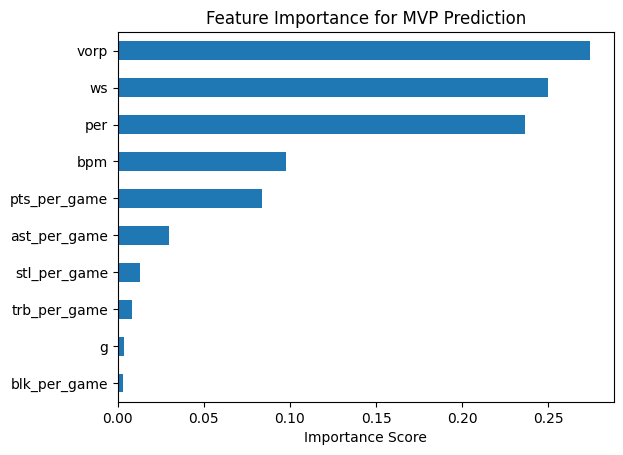

In [73]:
feat_importance = pd.Series(model2.feature_importances_, index=features2)
feat_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance for MVP Prediction')
plt.xlabel('Importance Score')
plt.show()

In [74]:
df2['meets_games_threshold'] = (df2['g'] >= 65).astype(int)

features3 = ['pts_per_game', 'ast_per_game', 'trb_per_game', 
             'stl_per_game', 'blk_per_game', 'g', 'meets_games_threshold',
             'per', 'ws', 'bpm', 'vorp']

X3 = df2[features3].fillna(0)
y3 = df2['winner'].astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

model3 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model3.fit(X3_train, y3_train)

y3_pred = model3.predict(X3_test)
print(classification_report(y3_test, y3_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4100
           1       0.75      0.30      0.43        10

    accuracy                           1.00      4110
   macro avg       0.87      0.65      0.71      4110
weighted avg       1.00      1.00      1.00      4110



In [75]:
results = pd.DataFrame({
    'actual': y3_test.values,
    'probability': y3_probs
}, index=y3_test.index)

missed_mvps = results[(results['actual'] == 1)]
print(missed_mvps.sort_values('probability', ascending=False))

       actual  probability
15195       1         0.82
6867        1         0.62
3034        1         0.61
36489       1         0.29
34119       1         0.17
21171       1         0.09
25122       1         0.09
39680       1         0.07
24442       1         0.04
31681       1         0.02


In [76]:
low_scorers = df2.loc[missed_mvps.index, ['season', 'player', 'pts_per_game', 'ws', 'per', 'bpm']]
low_scorers['probability'] = missed_mvps['probability'].values
print(low_scorers.sort_values('probability'))


       season               player  pts_per_game    ws   per   bpm  \
31681    1994      Hakeem Olajuwon          27.3  14.3  25.3   6.8   
24442    2003           Tim Duncan          23.3  16.5  26.9   7.6   
39680    1980  Kareem Abdul-Jabbar          24.8  14.8  25.3   7.2   
21171    2007        Dirk Nowitzki          24.6  16.3  27.6   8.3   
25122    2002           Tim Duncan          25.5  17.8  27.0   7.6   
34119    1990        Magic Johnson          22.3  16.5  26.6  10.1   
36489    1986           Larry Bird          25.8  15.8  25.6   8.7   
3034     2024         Nikola Jokić          26.4  17.0  31.0  13.2   
6867     2021         Nikola Jokić          26.4  15.6  31.3  12.1   
15195    2013         LeBron James          26.8  19.3  31.6  11.7   

       probability  
31681         0.02  
24442         0.04  
39680         0.07  
21171         0.09  
25122         0.09  
34119         0.17  
36489         0.29  
3034          0.61  
6867          0.62  
15195         0.82 

In [77]:
teams = pd.read_csv("Team Summaries.csv")
print(teams.head())
print(teams.columns.tolist())

   season   lg               team abbreviation  playoffs   age     w     l  \
0    2026  NBA      Atlanta Hawks          ATL     False  25.2  46.0  36.0   
1    2026  NBA     Boston Celtics          BOS     False  26.9  56.0  26.0   
2    2026  NBA      Brooklyn Nets          BRK     False  23.5  20.0  62.0   
3    2026  NBA      Chicago Bulls          CHI     False  25.3  31.0  51.0   
4    2026  NBA  Charlotte Hornets          CHO     False  24.0  44.0  38.0   

     pw    pl  ...  tov_percent  orb_percent  ft_fga  opp_e_fg_percent  \
0  47.0  35.0  ...         12.3         24.4   0.181             0.546   
1  59.0  23.0  ...         11.2         29.2   0.167             0.523   
2  18.0  64.0  ...         14.3         23.6   0.212             0.571   
3  29.0  53.0  ...         13.3         23.1   0.191             0.553   
4  53.0  29.0  ...         13.5         30.5   0.200             0.540   

   opp_tov_percent  drb_percent  opp_ft_fga             arena    attend  \
0          

In [78]:
print(df2['team'].value_counts().head(10))
print(teams['abbreviation'].value_counts().head())

team
PHI    750
CLE    750
ATL    739
GSW    736
SAS    734
MIL    732
DET    726
DAL    725
IND    720
LAL    718
Name: count, dtype: int64
abbreviation
BOS    80
NYK    80
DET    69
LAL    66
PHI    63
Name: count, dtype: int64


In [79]:
# grab just what we need from teams
team_wins = teams[teams['lg'] == 'NBA'][['season', 'abbreviation', 'w']]
# merge into df2
df3 = df2.merge(team_wins, left_on=['season', 'team'], right_on=['season', 'abbreviation'], how='left')

print(df3['w'].isna().sum())
print(df3.shape)

0
(20550, 41)


In [81]:
features4 = ['pts_per_game', 'ast_per_game', 'trb_per_game', 
             'stl_per_game', 'blk_per_game', 'g', 'meets_games_threshold',
             'per', 'ws', 'bpm', 'vorp', 'w', 'mp_per_game']

X4 = df3[features4].fillna(0)
y4 = df3['winner'].astype(int)

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

model4 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model4.fit(X4_train, y4_train)

y4_pred = model4.predict(X4_test)
print(classification_report(y4_test, y4_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4100
           1       0.60      0.30      0.40        10

    accuracy                           1.00      4110
   macro avg       0.80      0.65      0.70      4110
weighted avg       1.00      1.00      1.00      4110



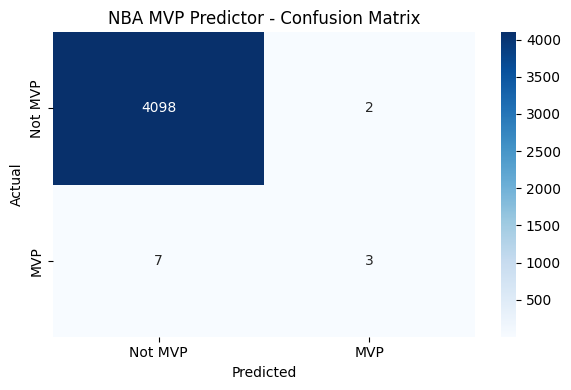

In [82]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y4_test, y4_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not MVP', 'MVP'],
            yticklabels=['Not MVP', 'MVP'])
plt.title('NBA MVP Predictor - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

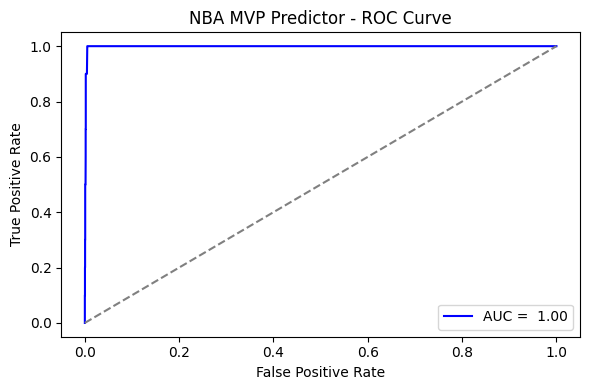

In [84]:
from sklearn.metrics import roc_curve, roc_auc_score

y4_probs = model4.predict_proba(X4_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y4_test, y4_probs)
auc = roc_auc_score(y4_test, y4_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc: .2f}')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.title("NBA MVP Predictor - ROC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()